In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [2]:
patientsData = pd.read_csv('AllData.csv')

Variable = Movement_Vigor_Score, beta = 0.6557290542413828, p-value = 8.28247285337959e-30


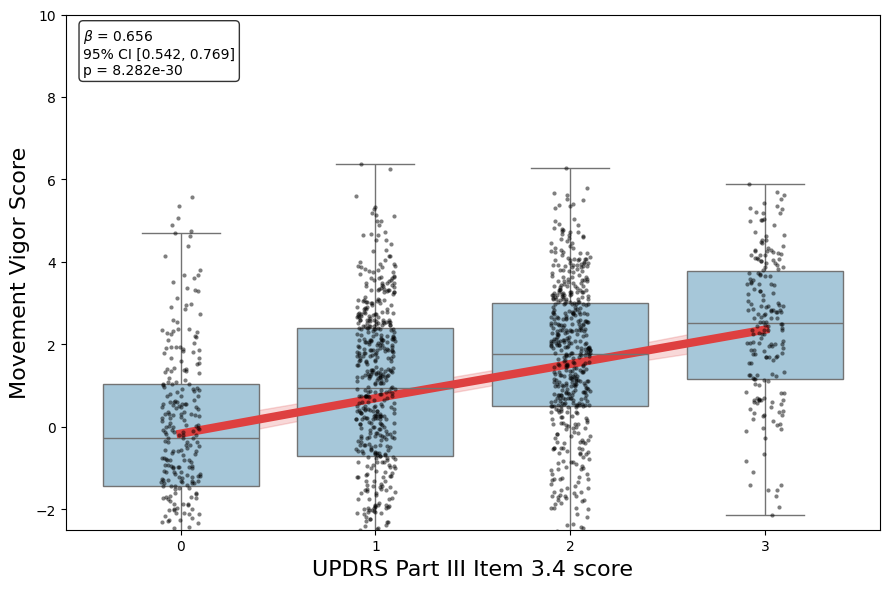

Variable = SequenceEffect_Score, beta = 0.6241213876106364, p-value = 9.42213211870706e-16


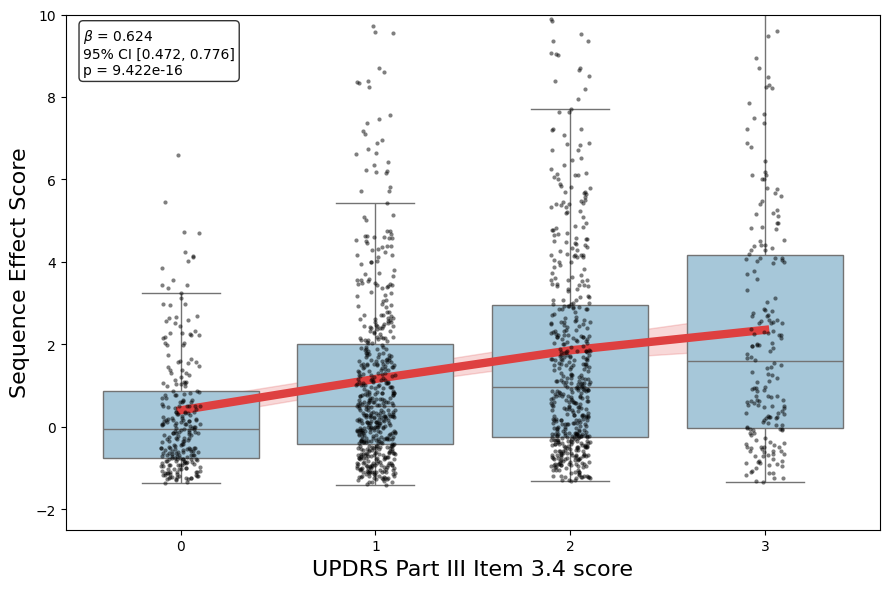

Variable = Movement_Irregularity_Score, beta = 1.246770966605392, p-value = 4.565769670419436e-47


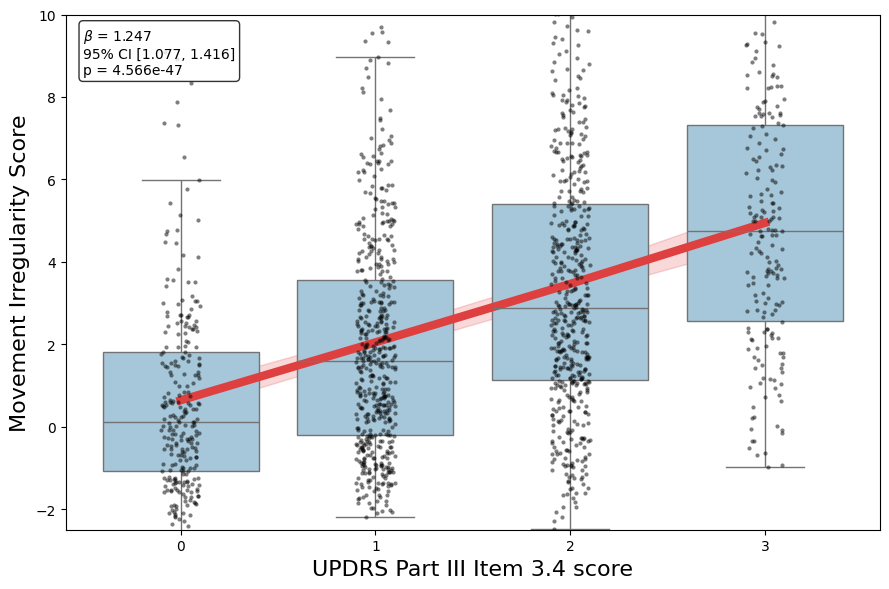

Variable = Timming_Score, beta = 0.9060980562847479, p-value = 9.791438686350488e-24


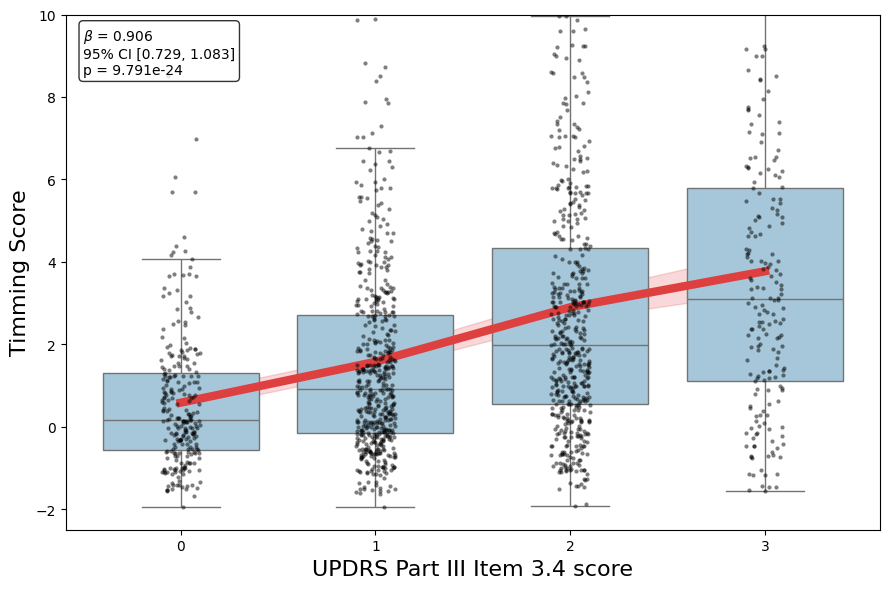

Variable = Pauses_and_Hesitations_Score, beta = 0.12299325822482765, p-value = 1.577341715218742e-10


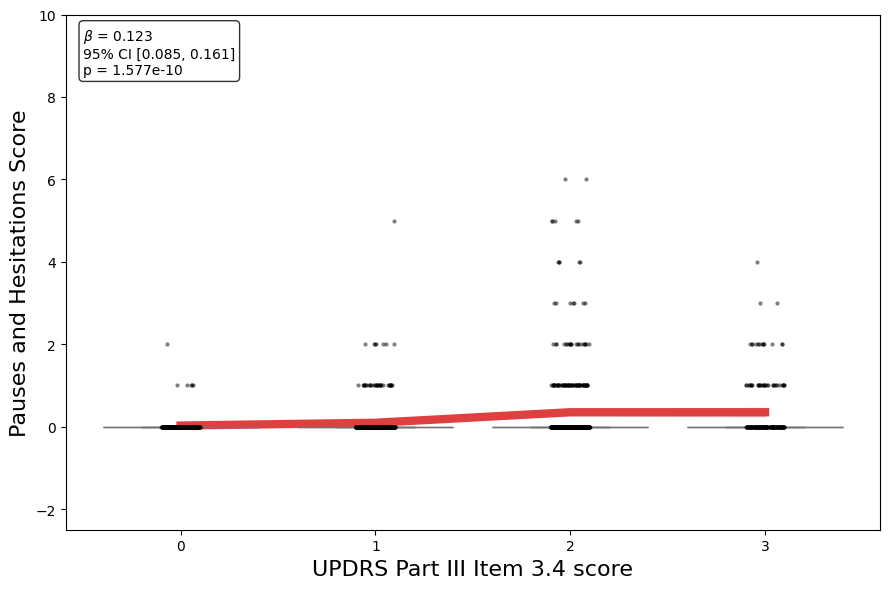

Variable = Final_Score, beta = 0.9889611260087078, p-value = 1.0998677868918693e-59


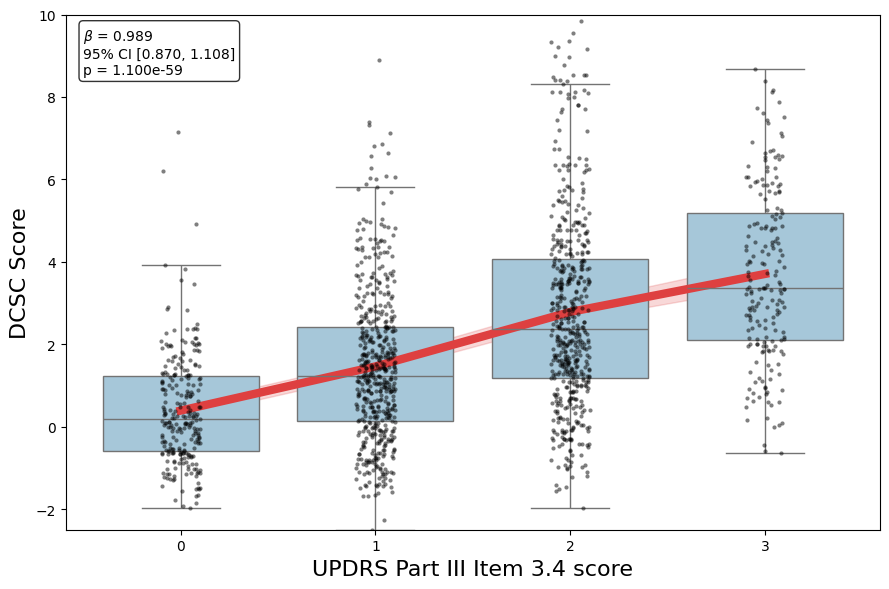

In [4]:
score_cols = [
            'Movement_Vigor_Score',
            'SequenceEffect_Score',
            'Movement_Irregularity_Score',
            'Timming_Score',
            'Pauses_and_Hesitations_Score',
        ]
y_labels= ['Movement Vigor', 'Sequence Effect', 'Movement Irregularity', 'Timming', 'Pauses and Hesitations', 'DCSC']  

# Box plots for each variable in score_cols (one figure per variable)
for feat, label in zip(score_cols + ['Final_Score'], y_labels[:len(score_cols)+1]):
    mask = patientsData['Item'].notna() & patientsData[feat].notna()
    plot_df = patientsData .loc[mask, ['Item', feat]].copy()
   

    fig, ax = plt.subplots(figsize=(9, 6))
    sns.boxplot(data=plot_df, x='Item', y=feat, ax=ax, color='#9ecae1', showfliers=False)
    

    ax.set_xlabel('UPDRS Part III Item 3.4 score', fontsize=16)
    ax.set_ylabel(f'{label} Score', fontsize=16)
    # ax.set_title(f'{label} by Clinical Score', fontsize=16)
    ax.set_xticks([0, 1, 2, 3])
    ax.set_ylim([-2.5,10])
    plt.tight_layout()

    model_df = patientsData[[feat, 'Item', 'Age', 'SubjectID']].dropna()

    # 3. Fit the Linear Mixed-Effects Model
    # Formula: 'Dependent_Variable ~ Fixed_Effect_1 + Fixed_Effect_2'
    # groups: The variable identifying the repeated measures (SubjectID)
    
    lmm_model = smf.mixedlm(f"{feat} ~ Item + Age", model_df, groups=model_df["SubjectID"], re_formula="1")
    result = lmm_model.fit()
    beta = result.params['Item']
    p = result.pvalues['Item']
    ci_ = result.conf_int().loc['Item'].values 
    print(f'Variable = {feat}, beta = {beta}, p-value = {p}')
    sns.stripplot(data=plot_df, x='Item', y=feat, ax=ax, color='black', alpha=0.5, size=3)
    sns.lineplot(x=patientsData['Item'], y=patientsData[feat],color="#DE4040", lw=6)
    # sns.regplot(x=patientsData['Item'], y=patientsData[feat], scatter_kws={'alpha':0.5}, line_kws={'color':"#202931"})

    plt.text( -0.5, 9.7, f"$\\beta$ = {beta:.3f}\n" f"95% CI [{ci_[0]:.3f}, {ci_[1]:.3f}]\n" f"p = {p:.3e}",  va='top',bbox=dict(boxstyle='round', facecolor='white', alpha=0.8) ) 
    plt.show()